# Project Final Report

### Due: Midnight on April 27th (2-hour grace period) — 50 points  

### No late submissions will be accepted.


## Overview

Your final submission consists of **two components**:


### 1. Team Final Report Notebook [50 pts]

Complete all sections of this notebook to document your final decisions, results, and broader context.

You will write a **technical report** following standard conventions. Useful references include:
- [CMU guide to structure](https://www.stat.cmu.edu/~brian/701/notes/paper-structure.pdf)
- [Data science report example](https://www.projectpro.io/article/data-science-project-report/620)
- The Checklist in this week’s Blackboard Lesson (aligned with HOML)

Your audience is **technically literate but unfamiliar with your work**—for example, your manager or other data scientists. Your report should be clear, precise, and well-organized, combining explanation, visualizations, and interpretation.

This Final Report is distinct from Milestone 2:

- **Milestone 2** serves as a repository of your working code and experiments  
- **This Final Report** presents a clear, structured summary of your project for a professional audience  

> **Important:**
> - Do **not** assume that readers of this report are familiar with Milestone 2. Your report should stand on its own.
> - Do not include full code or code cells in this notebook. All code was submitted in Milestone 2. This report should focus on explanation, results, and interpretation.
> - **Do not add, delete, or move cells in this notebook.** Each answer must be written entirely within its assigned Markdown cell.
> - All answers should be inserted directly under the appropriate `Answer:` prompt. Delete the sentence "Replace this sentence with your answer" and replace it with your response.
> - You may use any appropriate Markdown formatting (paragraphs, lists, tables, inserted graphics, LaTeX, etc.).
> - Submit this notebook as a group via your team leader’s Gradescope account.


### 2. Individual Assessment [0 points]

Each team member must **individually** complete the Final Project Individual Assessment Form (similar to Milestone 1), sign it, and upload it via their own Gradescope account.

**Due:** May 5th @ 2:00 AM



## Submission Checklist

- Final Report Notebook — submitted by team leader  
- Individual Assessment Form — submitted by each team member  



## 1. Executive Summary [4 pts]

Write a 300–400 word executive summary for a **non-technical audience**, such as business stakeholders in a real estate company.

Your summary should explain:
- the objective of the project
- key insights about the data
- the most important findings, including a plain-language description of model performance
- a clear recommendation or takeaway

Avoid technical detail and jargon. Focus on what matters and why. 

**1.1 Answer:**  
Our team was tasked with building a model to predict property values using readily available public information from Zillow. The dataset contained approximately 90,000 records from Los Angeles County, detailing each home’s size, location, and other physical characteristics. After data cleansing and testing multiple modeling approaches, we discovered that property location and home size are the strongest drivers of assessed value, with the home’s square footage, latitude and longitude coordinates, and its bathroom count repeatedly emerging as the most important predictors. This aligns with the well-known belief that location and size are the determinants of a home’s value. Our best-performing model, Random Forest, achieved a mean absolute error of approximately $164,000. Which is to say, on average, our predictions fall within about $164,000 of the actual assessed value, whether that be above or below the assessed amount. While this margin is meaningful in dollar terms, it is reasonable given the wide range of property values in the Los Angeles market, where homes ranged from less than $100,000 to several million dollars. The model captures the broad patterns in property valuation effectively, though it is less precise for the highest- and lowest-value homes. Based on our observations, we recommend adopting this model as a first-pass valuation tool for screening and prioritizing properties. It can help identify undervalued or overvalued listings quickly, whilst saving analysts significant time. However, for high-stakes decisions such as final pricing or investment offers, these predictions should be supplemented with local market knowledge and professional appraisals. Future improvements include incorporating neighborhood-level amenities, school ratings, and recent sale prices of comparable homes to reduce prediction error further. 

## 2. Introduction [3 pts]

Introduce the topic, context, and goals of your project.

You may imagine that this project was completed for a **real estate company with a small in-house data science team**.

Include all of the following:

- Clearly introduce the topic and context of your project
- Describe the problem you are addressing (the problem statement) and the overall motivation for solving it
- Clearly state the objectives and goals of your analysis (as different from the motivation)

**2.1 Answer:**  
Accurate property valuation is a cornerstone of the real estate industry. Whether a firm is advising clients on listing prices, identifying investment opportunities, or assessing portfolio risk, the ability to estimate a home's value quickly and reliably provides a significant competitive advantage. Traditional appraisals, while thorough, are time-consuming and expensive, making them impractical for large-scale screening of properties across an entire market.
This project addresses the challenge of predicting residential property tax assessed values in Los Angeles County using publicly available Zillow housing data. Property tax assessments serve as a useful proxy for market value, and accurately modeling them can help a real estate company flag mispriced properties, allocate resources for deeper analysis, and support data-driven decision-making across the organization.
The motivation for this work is practical: our hypothetical client, a real estate company with a small in-house data science team, needs a scalable, automated approach to property valuation that complements its analysts' judgment. Rather than replacing expert appraisals, the goal is to provide a reliable first-pass estimate that narrows the field and highlights where human attention is most needed.
Specifically, the objectives of this analysis are threefold. First, we aim to identify which property characteristics — such as size, location, and room count — are the strongest predictors of assessed value. Second, we seek to build and compare several regression models to determine which approach best captures the data's patterns. Third, we aim to deliver a final, tuned model with clearly reported performance metrics, along with an honest analysis of its strengths and limitations, so that investors can make informed decisions about when and how to rely on its predictions.

## 3. Data Description [3 pts]

Describe the dataset used in your analysis.

Include:
- the source of the dataset
- the number of observations (samples) and features
- the types of variables
- the target variable
- missing values or other important issues in the raw data

**3.1 Answer:**  
The dataset used in this analysis is derived from the Zillow Prize competition hosted on Kaggle, provided to our team through the Boston University CS 505 course. It contains residential property records from Los Angeles County, California. Variables included physical characteristics such as finished square footage, bedroom count, bathroom count, room count, and year built; location-based features such as latitude, longitude, FIPS code, ZIP code region ID, city region ID, and county region ID; and administrative fields such as parcel ID, assessment year, and census tract identifiers.
The majority of features were numeric, including both continuous variables (e.g., square footage, latitude) and discrete counts (e.g., bedrooms, bathrooms). A small number of categorical variables were also present, most notably propertycountylandusecode, which identifies the land use classification of each parcel.
The target variable is taxvaluedollarcnt, which represents the total tax-assessed value of the property in dollars. This serves as our proxy for property market value.
The raw data presented several notable quality issues. Many features had substantial amounts of missing data — some columns had upward of 50,000 null values out of roughly 90,000 records and were dropped entirely. A second tier of columns with 20,000-50,000 missing values was also removed. For the remaining features, missing numeric values were imputed using the column median, and missing categorical values were filled with the mode. Additionally, the target variable itself contained missing values, which were dropped prior to modeling. Outliers in the target variable were addressed by filtering to the 1st through 99th percentiles, removing extreme values at both ends of the distribution. Several redundant or uninformative columns — such as parcel ID, assessment year, and census tract identifiers — were also dropped early in the cleaning process.

## 4. Methodology (What you did, and why) [20 pts]

Focus on the **process and your reasoning**, not the results.

Note: Each subsection (e.g., 4.1, 4.2, etc.) must be answered in its own Markdown cell.  Each subsection is worth 5 points. 

### 4.1 Analytical Framework

Describe your overall approach.

Include:
- your overall framework
- use of validation curves
- choice of MAE or RMSE (as appropriate) as the primary error metric

**4.1 Answer:**  
Our Overall Analytical framework consists of a standard supervised machine learning process focused on predicting home tax values using property characteristics from zillow house listings. We began by completing exploratory data analyses which eventually led us to out cleaning and preprocessing opportunities for this dataset. One the data was fully cleaned and preprocessed, the next step was to separate the target variable from all of the predictor variables, and split the data into training and testing sets. We evaluated multiple models using repeated cross-validation to ensure performance was stable across different data splits rather than depending on a single random sample. Validation curves across cross validation results were used during tuning to compare training and validation error. This helped us to avoid over or under fitting. When we built our models, we laregely stuck to MAE to determine model performance as it is easy to interpret in terms of dollars compared to our existing data and is less sensitive to extreme prediction errors. Since this dataset at times contained serious outliers across multiple variables, MAE was chosen to give a more stable output of error prediction. 

### 4.2 Data Cleaning and Preprocessing

Describe how you prepared the data.

Include:
- issues in the raw data
- handling of missing values, outliers, inconsistencies
- key decisions and why
- what worked and what did not work

**4.2 Answer:**  
The raw dataset contained several attributes that needed signifigant cleaning before use. The first glaring issue was the missing values. Several potenital predictor variables had very high null counts (up to 90+% for some). We decided it was best to remove all variables with excess amounts of null values to avoid excess model noise. Rows missing the target value were also dropped as they do not be used for supervised learning models if they do not contain the target value at all. Additional efforts were made such as trimming some of the identifying column fields as there were more than one columns that only serves the purpose of identifying a property and did not tell us anything about is value. All of these preprocessing steps made the data easier to work with overall aswell as improved model efficency and performance. 


### 4.3 Feature Engineering

Describe your feature engineering.

Include:
- transformations or new features
- why you created them
- which were useful or not useful
- what worked and what did not work

**4.3 Answer:**  
One important improvement we made was creating log_calculatedfinishedsquarefeet, which applied a logarithmic transformation to the square footage of each property, reducing the skew in property size data nd improving model performance compared to using raw swuare footage only. We also used one-hot enocoding on the propertycountylandusecode variable allowing models to distinguish between  the different land use categories in a numerical fashion. Standardizing numeric variables was also something we explored to account for linear type models such as linear regression or ridge regressions that are sensitive to scaling. Forward feature selection was also used to identifying the most powerful predictor variables. These included square footage, latitude, longitude, bathrooms, bedrooms, zip code, and yuear built. The logarithmic transformation of square footage proved to be useful, while the scaling efforts had less impact on the tree based models such as Random Forest. 

### 4.4 Model Selection

Describe how you selected your model.

Include:
- models you tried and why
- how you evaluated generalization
- hyperparameter tuning
- how you chose the final model

**4.4 Answer:**  
The total of all models we built over the course of this projhect included linear regression, ridge regression, random forest, and gradient boosting. Linear and ridge regression were largely included as interperatable baselines, while random forest and gradient boosting were tested as they are made for building around non-linear relationships and feature interaction. Performance was measured using repeated 5-fold cross-validation with MAE scoring, along with final evaluation on the test set. Parameter tuning was completed using GridSearchCV for Ridge Regression and RandomizedSearchCV for Random Forest and Gradient Boosting. Parameters such as alpha, number of estimators, learning rate, depth, and minimum split size were optimized. After tuning, Gradient Boosting produced the best overall validation performance and was chosen as the final model because it achieved the lowest MAE. 

## 5. Results and Evaluation (What you found, and how well it worked) [16 pts]

Focus on **results, evidence, and interpretation**.

Note: Each subsection (e.g., 5.1, 5.2, etc.) must be answered in its own Markdown cell. 

### 5.1 Model Performance (6 points)

Briefly interpret what your metrics mean in practical terms.

Include:
- key metrics (e.g., RMSE, $R^2$)
- comparison across models
- comparison of training vs validation/test performance

**5.1 Answer:**  
The key metric to assess model performance was Mean Absolute Error (MAE). Mean absolute error describes the average distance from the actual values when a prediction is made.

Three models were tested using forward feature selection reporting MAE:  
1) Linear Regression - 203630.18  
2) Ridge Regression - 203629.21  
3) Random Forest Regression  - 169224.05  

A gradient boosting regression was trained and compared to the held out testing set. The training MAE was 163363.32, and the testing MAE was 165311.76.

### 5.2 Visualizations (5 points)

Graphics should be made as screenshots and dragged into the Markdown cell. Do NOT add code cells to create graphics. Each visualization must be clearly labeled and explained in the text.

Include:
- relevant plots with titles and labels
- explanation of what each plot shows
- why each visualization matters

**5.2 Answer:**  
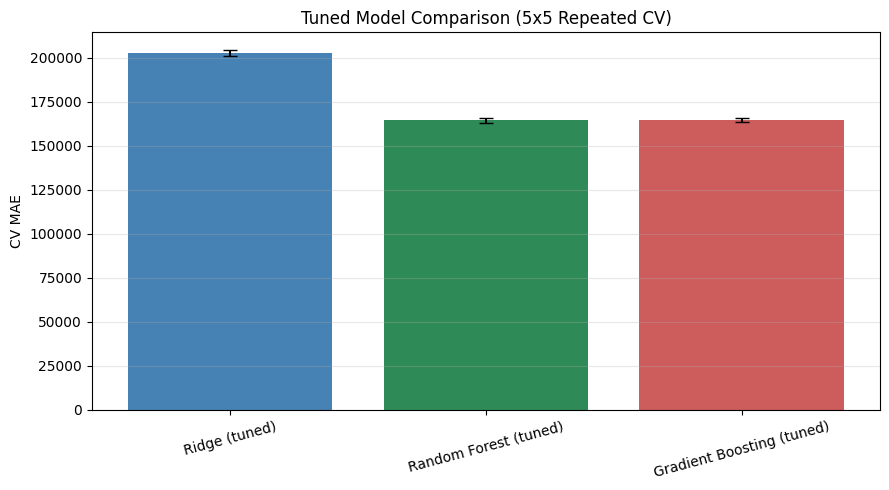

The figure presents a comparison of cross-validated mean absolute error for three tuned models evaluated using a 5×5 repeated cross validation framework. Among the models, the tuned Ridge regression exhibits the highest MAE (202592.93 ± 1514.10), indicating comparatively weaker predictive performance. In contrast, both the tuned Random Forest and Gradient Boosting models achieve substantially lower MAE values (164283.29 ± 1268.68 and 164452.92 ± 1174.06 respectively), demonstrating superior accuracy. The minimal size of the error bars across all models suggests low variability in performance across validation folds, reinforcing the reliability of these results. Overall, the findings indicate that tree based methods significantly outperform the linear Ridge model for this task, while Random Forest and Gradient Boosting perform at nearly equivalent levels.

### 5.3 Error Analysis (5 points)

Include:
- patterns in residuals or prediction errors
- overprediction or underprediction
- outliers or unusual observations
- anything surprising or worth improving

**5.3 Answer:**  
The model tends to overpredict for lower actual values and underpredict for higher ones. This pattern reflects a regression toward the mean, indicating that the model compresses predictions toward the center and struggles to accurately capture extreme values, suggesting incomplete modeling of underlying relationships in the data. The spread of residuals increases with higher predicted values, meaning that errors are relatively small and stable for low predictions but become larger and more variable as predictions increase. This non-constant error variance implies that the model’s reliability deteriorates for higher-value observations. Due to the over and underpredictions, it would be useful to create a transformation on the target variable in order to improve model accuracy at higher values.

## 6. Conclusion [4 pts]

Summarize your findings and implications.

Include all the following:

- Clearly state your main findings and how they address your original objectives
- Highlight any business or practical implications of your findings 
- Discuss the limitations and constraints of your analysis clearly and transparently
- Suggest potential improvements or future directions
- Conclude with a final recommendation addressing the business objective

**6.1 Answer:**  
Property characteristics such as square footage, location, and property land usage emerge as the strongest predictors of assessed value, reinforcing their importance in real estate valuation. In comparing models, tree-based ensemble methods—namely Random Forest and Gradient Boosting consistently outperform the linear Ridge model, indicating that the underlying relationships in the data are nonlinear and involve complex interactions. While the tuned ensemble models achieve lower cross-validated MAE and demonstrate stable performance, diagnostic plots reveal important limitations, namely systematic bias. Specifically, the model tends to overpredict lower value properties and underpredict higher value ones, with error variability increasing at higher predicted values. These findings collectively satisfy the project’s goals of identifying key drivers, selecting an effective modeling approach, and evaluating performance in a transparent and meaningful way.

From a practical standpoint, the model provides clear value as a scalable, first-pass valuation tool for a real estate firm. It enables rapid screening of large property datasets, helping identify potentially mispriced assets and prioritize opportunities for further analysis. However, its reduced reliability at the higher end of the market suggests that high value properties should still receive closer human evaluation, reinforcing the model’s role as a decision support tool rather than a replacement for expert judgment. Several limitations should be acknowledged, including reliance on publicly available data that may omit important variables, the use of tax assessments as a proxy for true market value, and limited geographic scope. Future improvements could include applying target transformations to reduce bias, enhancing feature engineering, incorporating additional data sources, and potentially segmenting the model by price range.Overall, it is recommended that the firm deploy the tuned ensemble model as part of its analytical workflow to support data-driven decision-making, while maintaining human oversight for high-stakes or complex valuation scenarios.